In [ ]:
import pandas as pd
import math
import os
import cv2

# --- Configuration ---
IMG_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/augmented_images"
CSV_PATH = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/augmented_annotations.csv"
LABEL_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/labels"

os.makedirs(LABEL_DIR, exist_ok=True)
df = pd.read_csv(CSV_PATH)

print("Converting CSV to YOLO-Pose labels...")

for img_name in df['image'].unique():

    img_path = os.path.join(IMG_DIR, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w = img.shape[:2]

    label_path = os.path.join(
        LABEL_DIR,
        os.path.splitext(img_name)[0] + ".txt"
    )

    img_rows = df[df['image'] == img_name]

    with open(label_path, 'w') as f:

        for _, row in img_rows.iterrows():

            # Bounding box
            bw, bh = row['bbox_w'], row['bbox_h']

            nx_center = (row['bbox_x'] + bw / 2) / w
            ny_center = (row['bbox_y'] + bh / 2) / h

            nw = bw / w
            nh = bh / h

            # Keypoints
            cx, cy = row['center_x'], row['center_y']

            angle_rad = math.radians(row['angle_deg'])

            R = min(bw, bh) / 2.0

            # Joint
            jx = cx - R * math.cos(angle_rad)
            jy = cy + R * math.sin(angle_rad)

            # Tab
            tx = cx + R * math.cos(angle_rad)
            ty = cy - R * math.sin(angle_rad)

            # Clamp values
            line = [
                0,

                max(0, min(1, nx_center)),
                max(0, min(1, ny_center)),
                max(0, min(1, nw)),
                max(0, min(1, nh)),

                max(0, min(1, jx / w)),
                max(0, min(1, jy / h)),
                2,

                max(0, min(1, cx / w)),
                max(0, min(1, cy / h)),
                2,

                max(0, min(1, tx / w)),
                max(0, min(1, ty / h)),
                2
            ]

            # Keep class id integer
            f.write(
                f"0 {' '.join(f'{val:.6f}' for val in line[1:])}\n"
            )

print(f"Labels saved to {LABEL_DIR}")

Converting CSV to YOLO-Pose labels...
Labels saved to /content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/labels


In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.3 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO

# Load model
model = YOLO('yolov8n-pose.pt')

print("Ultralytics loaded successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics loaded successfully


In [2]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.5 MB/s eta 0:00:00


In [ ]:
import os
import random
import shutil
from glob import glob

BASE = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026"

IMG_SRC = BASE + "/augmented_images"
LBL_SRC = BASE + "/labels"

IMG_DST = BASE + "/images"
LBL_DST = BASE + "/labels_split"

os.makedirs(IMG_DST + "/train", exist_ok=True)
os.makedirs(IMG_DST + "/val", exist_ok=True)

os.makedirs(LBL_DST + "/train", exist_ok=True)
os.makedirs(LBL_DST + "/val", exist_ok=True)

images = glob(IMG_SRC + "/*")

random.shuffle(images)

split = int(0.8 * len(images))

train_imgs = images[:split]
val_imgs = images[split:]

def move_files(img_list, split_name):

    for img_path in img_list:

        name = os.path.basename(img_path)

        label_name = os.path.splitext(name)[0] + ".txt"

        label_path = os.path.join(LBL_SRC, label_name)

        shutil.copy(
            img_path,
            os.path.join(IMG_DST, split_name, name)
        )

        if os.path.exists(label_path):
            shutil.copy(
                label_path,
                os.path.join(LBL_DST, split_name, label_name)
            )

move_files(train_imgs, "train")
move_files(val_imgs, "val")

print("Done")
print("Train:", len(train_imgs))
print("Val:", len(val_imgs))

Done
Train: 280
Val: 70


In [ ]:
import glob
import os

for f in glob.glob("/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/labels/*.cache"):
    os.remove(f)

for f in glob.glob("/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/labels/**/*.cache", recursive=True):
    os.remove(f)

print("cache removed")

cache removed


In [ ]:
from ultralytics import YOLO

# Load the pretrained Pose model
model = YOLO('yolov8n-pose.pt')

# Train
model.train(
    data='/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/pose_config.yaml',
    epochs=40,
    imgsz=640,
    batch=16,
    name='tube_pose_v1',
    degrees=0.0,
    flipud=0.0,
    fliplr=0.0,
)

# Your best model will be saved at:
# runs/pose/tube_pose_v1/weights/best.pt

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/pose_config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=0.1, multi_scale=0.0, name=tube_pose_v1-14, nbs=64, nms=False, opset=None, op

ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ea8548240b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034, 

In [ ]:
def get_angle_from_pose(kpts):
    """
    kpts: list of 3 keypoints [[jx, jy], [cx, cy], [tx, ty]]
    Returns: angle in degrees [0, 360)
    """
    jx, jy = kpts[0]
    tx, ty = kpts[2]

    # Vector from Joint to Tab
    dx = tx - jx
    dy = jy - ty # Image Y is inverted

    angle_rad = math.atan2(dy, dx)
    angle_deg = (math.degrees(angle_rad) + 360) % 360
    return angle_deg

In [5]:
from ultralytics import YOLO
import math
import os
import cv2

# --- Configuration ---
# Update this to match your trained weights path from the logs
POSE_MODEL_PATH = "/content/best (1).pt"
IMG_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/augmented_images"

print("Loading pose model...")
pose_model = YOLO(POSE_MODEL_PATH)

def get_angle_from_pose(kpts):
    """
    kpts: list of 3 keypoints [[jx, jy], [cx, cy], [tx, ty]]
    Calculates angle based on Joint-to-Tab vector.
    """
    jx, jy = kpts[0] # Joint
    tx, ty = kpts[2] # Tab


    dx = tx - jx
    dy = jy - ty

    angle_rad = math.atan2(dy, dx)
    angle_deg = (math.degrees(angle_rad) + 360) % 360
    return angle_deg

def run_pose_inference(image_name):
    img_path = os.path.join(IMG_DIR, image_name)

    # Run inference
    results = pose_model(img_path, verbose=False)[0]

    predictions = []

    # Check if keypoints were detected
    if results.keypoints is not None and results.keypoints.xy is not None:
        # Extract the keypoint coordinates
        kpts_array = results.keypoints.xy.cpu().numpy()

        for kpts in kpts_array:
            if len(kpts) == 3:
                # Get the predicted center (index 1)
                center_x, center_y = kpts[1]

                # Calculate the angle using Joint and Tab
                angle = get_angle_from_pose(kpts)

                predictions.append([center_x, center_y, angle])

    return predictions

# Quick test
# print(run_pose_inference("some_image_name.png"))

Loading pose model...


In [6]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

# --- Configuration ---
ANNOT_PATH = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/augmented_annotations.csv"
MATCH_THRESHOLD = 30.0 # Max pixel distance to consider a match

df = pd.read_csv(ANNOT_PATH)

def get_angle_error(pred_deg, gt_deg):
    diff = abs(pred_deg - gt_deg)
    return min(diff, 360.0 - diff)

def evaluate_predictions(preds, gts):
    if len(preds) == 0:
        return 0, 0, len(gts), []

    preds_arr = np.array(preds)
    gts_arr = np.array(gts)

    pred_centers = preds_arr[:, :2]
    gt_centers = gts_arr[:, :2]

    # Match using Hungarian algorithm
    dist_matrix = cdist(pred_centers, gt_centers)
    row_ind, col_ind = linear_sum_assignment(dist_matrix)

    tp, fp, fn = 0, 0, 0
    angle_errors = []

    matched_preds = set()
    matched_gts = set()

    for r, c in zip(row_ind, col_ind):
        if dist_matrix[r, c] <= MATCH_THRESHOLD:
            tp += 1
            matched_preds.add(r)
            matched_gts.add(c)

            # Calculate angle error for True Positives
            err = get_angle_error(preds_arr[r, 2], gts_arr[c, 2])
            angle_errors.append(err)

    fp = len(preds) - len(matched_preds)
    fn = len(gts) - len(matched_gts)

    return tp, fp, fn, angle_errors

# --- Main Evaluation Loop ---
unique_images = df['image'].unique()
print(f"Evaluating on {len(unique_images)} images...\n")

total_tp, total_fp, total_fn = 0, 0, 0
all_angle_errors = []

for img_name in unique_images:
    # 1. Ground Truth
    gt_rows = df[df['image'] == img_name]
    gts = gt_rows[['center_x', 'center_y', 'angle_deg']].values.tolist()

    # 2. Predictions
    preds = run_pose_inference(img_name)

    # 3. Evaluate Match
    tp, fp, fn, errs = evaluate_predictions(preds, gts)

    total_tp += tp
    total_fp += fp
    total_fn += fn
    all_angle_errors.extend(errs)

# --- Final Report ---
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
mae = np.mean(all_angle_errors) if all_angle_errors else 0

print(f"--- YOLO-Pose Results ---")
print(f"Centers Detected: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")
print(f"Angle Mean Abs Error (MAE): {mae:.2f} degrees")
print(f"(TP: {total_tp}, FP: {total_fp}, FN: {total_fn})")

Evaluating on 350 images...

--- YOLO-Pose Results ---
Centers Detected: Precision=0.937, Recall=1.000, F1=0.967
Angle Mean Abs Error (MAE): 5.28 degrees
(TP: 1852, FP: 125, FN: 0)


In [9]:
import os
import math
import numpy as np
import pandas as pd
import cv2
from ultralytics import YOLO
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

# ==========================================
# 1. TEST CONFIGURATION (Update these paths)
# ==========================================
POSE_MODEL_PATH = "/content/best (1).pt"
TEST_IMG_DIR = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/images/val"
TEST_CSV_PATH = "/content/drive/MyDrive/TubeDetectionDataset_ZeonSystems2026/annotations.csv"

MATCH_THRESHOLD = 30.0

print("Loading model and test data...")
pose_model = YOLO(POSE_MODEL_PATH)
df_test = pd.read_csv(TEST_CSV_PATH)

# ==========================================
# 2. CORE LOGIC
# ==========================================
def get_angle_from_pose(kpts):
    jx, jy = kpts[0] # Joint
    tx, ty = kpts[2] # Tab
    dx = tx - jx
    dy = jy - ty
    angle_rad = math.atan2(dy, dx)
    return (math.degrees(angle_rad) + 360) % 360

def run_pose_inference(img_path):
    results = pose_model(img_path, verbose=False)[0]
    predictions = []

    if results.keypoints is not None and results.keypoints.xy is not None:
        kpts_array = results.keypoints.xy.cpu().numpy()
        for kpts in kpts_array:
            if len(kpts) == 3:
                center_x, center_y = kpts[1]
                angle = get_angle_from_pose(kpts)
                predictions.append([center_x, center_y, angle])
    return predictions

def get_angle_error(pred_deg, gt_deg):
    diff = abs(pred_deg - gt_deg)
    return min(diff, 360.0 - diff)

def evaluate_predictions(preds, gts):
    if len(preds) == 0:
        return 0, 0, len(gts), []

    preds_arr, gts_arr = np.array(preds), np.array(gts)
    dist_matrix = cdist(preds_arr[:, :2], gts_arr[:, :2])
    row_ind, col_ind = linear_sum_assignment(dist_matrix)

    tp, fp, fn = 0, 0, 0
    angle_errors = []
    matched_preds, matched_gts = set(), set()

    for r, c in zip(row_ind, col_ind):
        if dist_matrix[r, c] <= MATCH_THRESHOLD:
            tp += 1
            matched_preds.add(r)
            matched_gts.add(c)
            err = get_angle_error(preds_arr[r, 2], gts_arr[c, 2])
            angle_errors.append(err)

    fp = len(preds) - len(matched_preds)
    fn = len(gts) - len(matched_gts)
    return tp, fp, fn, angle_errors

# ==========================================
# 3. EVALUATION LOOP
# ==========================================
unique_images = df_test['image'].unique()
print(f"Running inference on {len(unique_images)} test images...\n")

total_tp, total_fp, total_fn = 0, 0, 0
all_angle_errors = []

for img_name in unique_images:
    # Get Ground Truth
    gt_rows = df_test[df_test['image'] == img_name]
    gts = gt_rows[['center_x', 'center_y', 'angle_deg']].values.tolist()

    # Get Predictions
    img_path = os.path.join(TEST_IMG_DIR, img_name)
    if not os.path.exists(img_path): continue

    preds = run_pose_inference(img_path)

    # Match and Score
    tp, fp, fn, errs = evaluate_predictions(preds, gts)
    total_tp += tp
    total_fp += fp
    total_fn += fn
    all_angle_errors.extend(errs)

# ==========================================
# 4. FINAL REPORT
# ==========================================
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
mae = np.mean(all_angle_errors) if all_angle_errors else 0

print(f"--- FINAL TEST SET RESULTS ---")
print(f"Centers Detected: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")
print(f"Angle Mean Abs Error (MAE): {mae:.2f} degrees")
print(f"(TP: {total_tp}, FP: {total_fp}, FN: {total_fn})")

Loading model and test data...
Running inference on 70 test images...

--- FINAL TEST SET RESULTS ---
Centers Detected: Precision=0.783, Recall=1.000, F1=0.878
Angle Mean Abs Error (MAE): 5.55 degrees
(TP: 72, FP: 20, FN: 0)


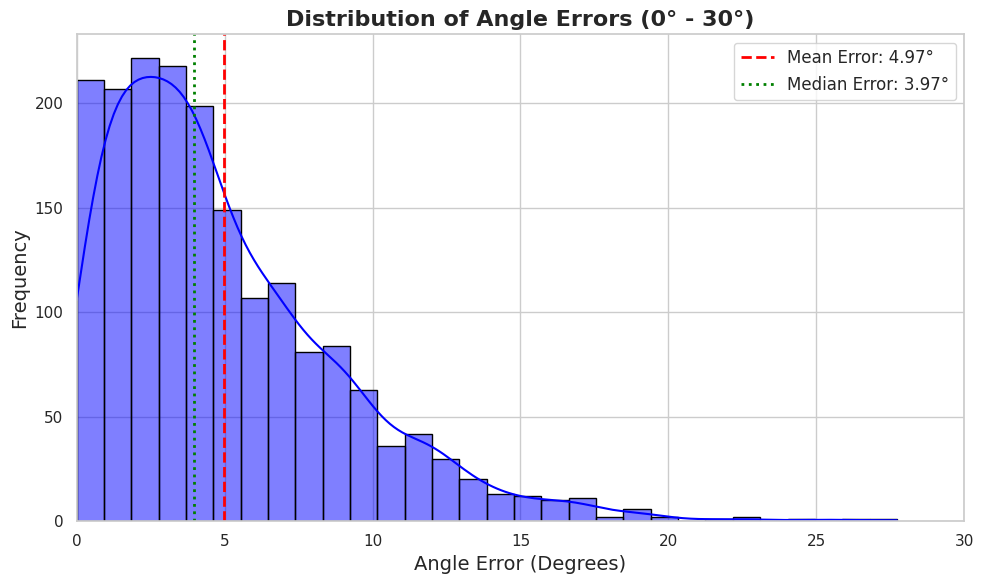

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style
sns.set_theme(style="whitegrid")

# Keep only errors between 0 and 30 degrees
filtered_errors = [e for e in all_angle_errors if 0 <= e <= 30]

# Create figure
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(
    filtered_errors,
    bins=30,
    kde=True,
    color='blue',
    edgecolor='black'
)

# Mean
mae = np.mean(filtered_errors)
plt.axvline(
    mae,
    color='red',
    linestyle='dashed',
    linewidth=2,
    label=f'Mean Error: {mae:.2f}°'
)

# Median
median = np.median(filtered_errors)
plt.axvline(
    median,
    color='green',
    linestyle='dotted',
    linewidth=2,
    label=f'Median Error: {median:.2f}°'
)

# Formatting
plt.title('Distribution of Angle Errors (0° - 30°)', fontsize=16, fontweight='bold')
plt.xlabel('Angle Error (Degrees)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Restrict x-axis
plt.xlim(0, 30)

plt.legend(fontsize=12)

# Show
plt.tight_layout()
plt.show()